## Taxi Trip Duration prediction
https://www.kaggle.com/competitions/nyc-taxi-trip-duration


Models used: Neural network - 0.47672, 0.47725

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_log_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [4]:
train = pd.read_csv("train (2).csv")
test = pd.read_csv("test (2).csv")
res = pd.read_csv("sample_submission (2).csv")

In [4]:
train

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435
...,...,...,...,...,...,...,...,...,...,...,...
1458639,id2376096,2,2016-04-08 13:31:04,2016-04-08 13:44:02,4,-73.982201,40.745522,-73.994911,40.740170,N,778
1458640,id1049543,1,2016-01-10 07:35:15,2016-01-10 07:46:10,1,-74.000946,40.747379,-73.970184,40.796547,N,655
1458641,id2304944,2,2016-04-22 06:57:41,2016-04-22 07:10:25,1,-73.959129,40.768799,-74.004433,40.707371,N,764
1458642,id2714485,1,2016-01-05 15:56:26,2016-01-05 16:02:39,1,-73.982079,40.749062,-73.974632,40.757107,N,373


In [5]:
train.info(memory_usage = 'deep')

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  str    
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  str    
 3   dropoff_datetime    1458644 non-null  str    
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  str    
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 417.3 MB


In [6]:
test.info(memory_usage = 'deep')

<class 'pandas.DataFrame'>
RangeIndex: 625134 entries, 0 to 625133
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  625134 non-null  str    
 1   vendor_id           625134 non-null  int64  
 2   pickup_datetime     625134 non-null  str    
 3   passenger_count     625134 non-null  int64  
 4   pickup_longitude    625134 non-null  float64
 5   pickup_latitude     625134 non-null  float64
 6   dropoff_longitude   625134 non-null  float64
 7   dropoff_latitude    625134 non-null  float64
 8   store_and_fwd_flag  625134 non-null  str    
dtypes: float64(4), int64(2), str(3)
memory usage: 133.5 MB


As we can see the <b>'dropoff_datetime'</b> column is missing from the test data, and it means that it was solely used in forming the original training dataset's trip duration target.

In [7]:
train.id.value_counts()

id
id2875421    1
id2377394    1
id3858529    1
id3504673    1
id2181028    1
            ..
id2376096    1
id1049543    1
id2304944    1
id2714485    1
id1209952    1
Name: count, Length: 1458644, dtype: int64

In [8]:
train.vendor_id.value_counts()

vendor_id
2    780302
1    678342
Name: count, dtype: int64

In [9]:
train = pd.get_dummies(train, columns = ['vendor_id'], dtype = 'int8')

In [10]:
train.store_and_fwd_flag = (train.store_and_fwd_flag == 'Y').astype('int8')

In [11]:
train['distance'] = 2*6371*np.arcsin(np.sqrt(np.sin(np.radians(train.pickup_latitude/2 - train.dropoff_latitude/2))**2+np.cos(np.radians(train.pickup_latitude))*np.cos(np.radians(train.dropoff_latitude))*np.sin(np.radians(train.pickup_longitude/2-train.dropoff_longitude/2))**2))

In [12]:
train

,id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,vendor_id_1,vendor_id_2,distance
0,id2875421,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,0,455,0,1,1.498521
1,id2377394,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,0,663,1,0,1.805507
2,id3858529,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,0,2124,0,1,6.385098
3,id3504673,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,0,429,0,1,1.485498
4,id2181028,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,0,435,0,1,1.188588
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458639,id2376096,2016-04-08 13:31:04,2016-04-08 13:44:02,4,-73.982201,40.745522,-73.994911,40.740170,0,778,0,1,1.225080
1458640,id1049543,2016-01-10 07:35:15,2016-01-10 07:46:10,1,-74.000946,40.747379,-73.970184,40.796547,0,655,1,0,6.049836
1458641,id2304944,2016-04-22 06:57:41,2016-04-22 07:10:25,1,-73.959129,40.768799,-74.004433,40.707371,0,764,0,1,7.824606
1458642,id2714485,2016-01-05 15:56:26,2016-01-05 16:02:39,1,-73.982079,40.749062,-73.974632,40.757107,0,373,1,0,1.092564


In [13]:
train.columns

Index(['id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration',
       'vendor_id_1', 'vendor_id_2', 'distance'],
      dtype='str')

In [14]:
train.drop(['id','pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude'],axis=1, inplace = True)

In [15]:
train

,pickup_datetime,dropoff_datetime,passenger_count,store_and_fwd_flag,trip_duration,vendor_id_1,vendor_id_2,distance
0,2016-03-14 17:24:55,2016-03-14 17:32:30,1,0,455,0,1,1.498521
1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,0,663,1,0,1.805507
2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,0,2124,0,1,6.385098
3,2016-04-06 19:32:31,2016-04-06 19:39:40,1,0,429,0,1,1.485498
4,2016-03-26 13:30:55,2016-03-26 13:38:10,1,0,435,0,1,1.188588
...,...,...,...,...,...,...,...,...
1458639,2016-04-08 13:31:04,2016-04-08 13:44:02,4,0,778,0,1,1.225080
1458640,2016-01-10 07:35:15,2016-01-10 07:46:10,1,0,655,1,0,6.049836
1458641,2016-04-22 06:57:41,2016-04-22 07:10:25,1,0,764,0,1,7.824606
1458642,2016-01-05 15:56:26,2016-01-05 16:02:39,1,0,373,1,0,1.092564


In [16]:
train.drop('dropoff_datetime', axis = 1, inplace = True)

In [17]:
train.pickup_datetime = pd.to_datetime(train.pickup_datetime)

In [18]:
train

,pickup_datetime,passenger_count,store_and_fwd_flag,trip_duration,vendor_id_1,vendor_id_2,distance
0,2016-03-14 17:24:55,1,0,455,0,1,1.498521
1,2016-06-12 00:43:35,1,0,663,1,0,1.805507
2,2016-01-19 11:35:24,1,0,2124,0,1,6.385098
3,2016-04-06 19:32:31,1,0,429,0,1,1.485498
4,2016-03-26 13:30:55,1,0,435,0,1,1.188588
...,...,...,...,...,...,...,...
1458639,2016-04-08 13:31:04,4,0,778,0,1,1.225080
1458640,2016-01-10 07:35:15,1,0,655,1,0,6.049836
1458641,2016-04-22 06:57:41,1,0,764,0,1,7.824606
1458642,2016-01-05 15:56:26,1,0,373,1,0,1.092564


In [19]:
train.columns

Index(['pickup_datetime', 'passenger_count', 'store_and_fwd_flag',
       'trip_duration', 'vendor_id_1', 'vendor_id_2', 'distance'],
      dtype='str')

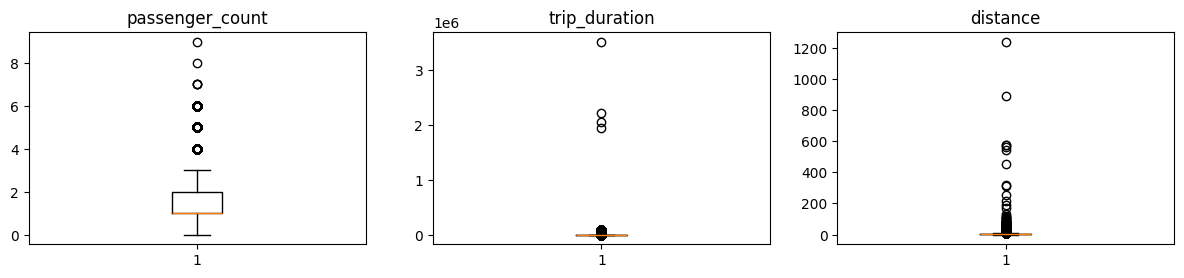

In [20]:
plt.figure(figsize = (20,16))
for j,i in enumerate(['passenger_count',
       'trip_duration', 'distance']):
    plt.subplot(5,4,j+1)
    plt.boxplot(train[i])
    plt.title(i)

In [21]:
train[train['trip_duration']>1e6].trip_duration.value_counts()

trip_duration
1939736    1
2049578    1
2227612    1
3526282    1
Name: count, dtype: int64

In [22]:
train = train[train.trip_duration <1e6]

In [23]:
train.passenger_count.value_counts()

passenger_count
1    1033537
2     210317
5      78088
3      59896
6      48333
4      28404
0         60
7          3
9          1
8          1
Name: count, dtype: int64

In [24]:
train[train['distance']>400].distance.value_counts()

distance
1240.908677    1
545.853499     1
578.842818     1
562.235188     1
891.214103     1
455.241204     1
574.875442     1
Name: count, dtype: int64

In [25]:
train = train[train.distance <= 400]

In [26]:
train

,pickup_datetime,passenger_count,store_and_fwd_flag,trip_duration,vendor_id_1,vendor_id_2,distance
0,2016-03-14 17:24:55,1,0,455,0,1,1.498521
1,2016-06-12 00:43:35,1,0,663,1,0,1.805507
2,2016-01-19 11:35:24,1,0,2124,0,1,6.385098
3,2016-04-06 19:32:31,1,0,429,0,1,1.485498
4,2016-03-26 13:30:55,1,0,435,0,1,1.188588
...,...,...,...,...,...,...,...
1458639,2016-04-08 13:31:04,4,0,778,0,1,1.225080
1458640,2016-01-10 07:35:15,1,0,655,1,0,6.049836
1458641,2016-04-22 06:57:41,1,0,764,0,1,7.824606
1458642,2016-01-05 15:56:26,1,0,373,1,0,1.092564


In [27]:
train['is_weekend'] = train.pickup_datetime.dt.day_of_week.isin([5,6]).astype('int8')
train['hours'] = train.pickup_datetime.dt.hour
train['minutes'] = train.pickup_datetime.dt.minute
train.drop('pickup_datetime', axis = 1, inplace = True)
train

,passenger_count,store_and_fwd_flag,trip_duration,vendor_id_1,vendor_id_2,distance,is_weekend,hours,minutes
0,1,0,455,0,1,1.498521,0,17,24
1,1,0,663,1,0,1.805507,1,0,43
2,1,0,2124,0,1,6.385098,0,11,35
3,1,0,429,0,1,1.485498,0,19,32
4,1,0,435,0,1,1.188588,1,13,30
...,...,...,...,...,...,...,...,...,...
1458639,4,0,778,0,1,1.225080,0,13,31
1458640,1,0,655,1,0,6.049836,1,7,35
1458641,1,0,764,0,1,7.824606,0,6,57
1458642,1,0,373,1,0,1.092564,0,15,56


<Axes: >

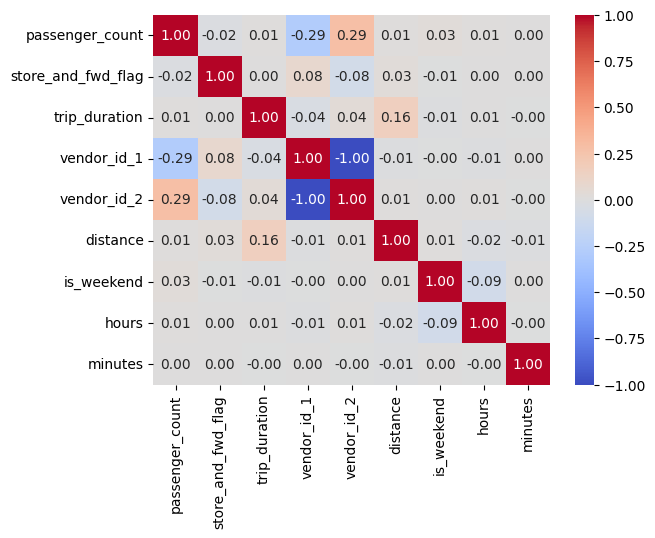

In [29]:
import seaborn as sns
sns.heatmap(train.corr(), annot = True, fmt = '.2f', cmap = 'coolwarm')

None of the features have strong positive or negative correlation with each other and with the target as well, one-hot-encoded vendor_id_1 and vendor_id_2 features have -1.00 correlation which is natural

In [7]:
def prep(x0):
    x = x0.copy()
    x = pd.get_dummies(x, columns = ['vendor_id'], dtype = 'int8')
    x.store_and_fwd_flag = (x.store_and_fwd_flag == 'Y').astype('int8')
    x['distance'] = 2*6371*np.arcsin(np.sqrt(np.sin(np.radians(x.pickup_latitude/2 - x.dropoff_latitude/2))**2+np.cos(np.radians(x.pickup_latitude))*np.cos(np.radians(x.dropoff_latitude))*np.sin(np.radians(x.pickup_longitude/2-x.dropoff_longitude/2))**2))
    x.drop(['id','pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
           'dropoff_latitude'],axis=1, inplace = True)
    x.pickup_datetime = pd.to_datetime(x.pickup_datetime)
    x['is_weekend'] = x.pickup_datetime.dt.day_of_week.isin([5,6]).astype('int8')
    x['hours'] = x.pickup_datetime.dt.hour
    x['minutes'] = x.pickup_datetime.dt.minute
    x.drop('pickup_datetime', axis = 1, inplace = True)
    return x

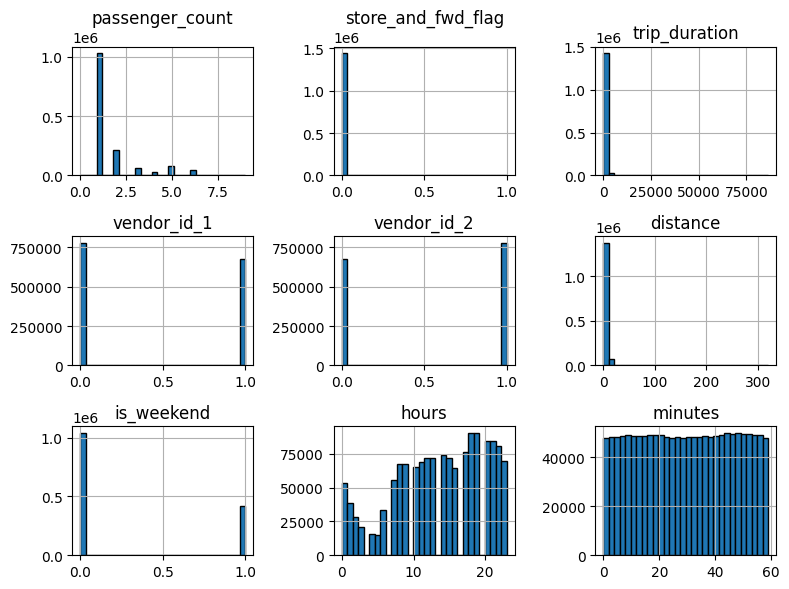

In [30]:
train.hist(figsize = (8,6), bins = 30, edgecolor = 'k')
plt.tight_layout()
plt.show()

In [60]:
NN = tf.keras.Sequential([
    tf.keras.Input(shape = (8,)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units = 128, activation = 'relu'),
    tf.keras.layers.Dense(units = 64, activation = 'relu'),
    tf.keras.layers.Dense(units = 32, activation = 'relu'),
    tf.keras.layers.Dense(units = 1, activation = 'linear')
])
NN.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
x = train.drop('trip_duration', axis = 1)
y = np.log1p(train['trip_duration']).values

In [51]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=0)
print(f'Train shape: {x_train.shape} {y_train.shape}')
print(f'Test shape: {x_test.shape} {y_test.shape}')

Train shape: (1166906, 8) (1166906,)
Test shape: (291727, 8) (291727,)


In [16]:
from sklearn.preprocessing import StandardScaler

In [55]:
xg = XGBRegressor()
xg.fit(x_train, y_train)
ypr = xg.predict(x_test)
# root_mean_squared_log_error(y_test, ypr)
ypr[ypr<=0]

array([], dtype=float32)

In [56]:
root_mean_squared_log_error(y_test, ypr)


0.0683582111883776

In [29]:
def rmsle(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(tf.math.log1p(y_pred) - tf.math.log1p(y_true))))

In [69]:
NN.compile(optimizer = 'adam', loss = 'mse', metrics = [rmsle])

In [72]:
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

In [78]:
his = NN.fit(x_train_sc, y_train, epochs = 10, batch_size = 50, validation_data = (x_test_sc, y_test))

Epoch 1/10
23339/23339 ━━━━━━━━━━━━━━━━━━━━ 58s 2ms/step - loss: 0.2240 - rmsle: 0.1396 - val_loss: 0.2225 - val_rmsle: 0.1418
Epoch 2/10
23339/23339 ━━━━━━━━━━━━━━━━━━━━ 62s 3ms/step - loss: 0.2240 - rmsle: 0.1396 - val_loss: 0.2235 - val_rmsle: 0.1417
Epoch 3/10
23339/23339 ━━━━━━━━━━━━━━━━━━━━ 57s 2ms/step - loss: 0.2239 - rmsle: 0.1396 - val_loss: 0.2231 - val_rmsle: 0.1403
Epoch 4/10
23339/23339 ━━━━━━━━━━━━━━━━━━━━ 62s 3ms/step - loss: 0.2237 - rmsle: 0.1396 - val_loss: 0.2217 - val_rmsle: 0.1407
Epoch 5/10
23339/23339 ━━━━━━━━━━━━━━━━━━━━ 61s 3ms/step - loss: 0.2235 - rmsle: 0.1396 - val_loss: 0.2218 - val_rmsle: 0.1411
Epoch 6/10
23339/23339 ━━━━━━━━━━━━━━━━━━━━ 62s 3ms/step - loss: 0.2235 - rmsle: 0.1396 - val_loss: 0.2221 - val_rmsle: 0.1397
Epoch 7/10
23339/23339 ━━━━━━━━━━━━━━━━━━━━ 61s 3ms/step - loss: 0.2236 - rmsle: 0.1396 - val_loss: 0.2234 - val_rmsle: 0.1416
Epoch 8/10
23339/23339 ━━━━━━━━━━━━━━━━━━━━ 63s 3ms/step - loss: 0.2235 - rmsle: 0.1396 - val_loss: 0.2232 - va

In [79]:
root_mean_squared_log_error(y_test,NN.predict(x_test_sc))

9117/9117 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


0.06928473016176724

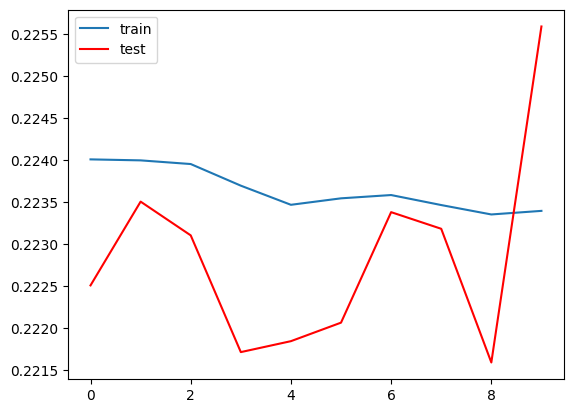

In [81]:
plt.plot(his.history['loss'],label='train')
plt.plot(his.history['val_loss'],c='r',label='test')
plt.legend()

In [8]:
test = prep(test)

In [9]:
train = prep(train)

In [85]:
NN_final = tf.keras.Sequential([
    tf.keras.Input(shape = (8,)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units = 128, activation = 'relu'),
    tf.keras.layers.Dense(units = 64, activation = 'relu'),
    tf.keras.layers.Dense(units = 32, activation = 'relu'),
    tf.keras.layers.Dense(units = 1, activation = 'linear')
])
NN_final.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
train

,dropoff_datetime,passenger_count,store_and_fwd_flag,trip_duration,vendor_id_1,vendor_id_2,distance,is_weekend,hours,minutes
0,2016-03-14 17:32:30,1,0,455,0,1,1.498521,0,17,24
1,2016-06-12 00:54:38,1,0,663,1,0,1.805507,1,0,43
2,2016-01-19 12:10:48,1,0,2124,0,1,6.385098,0,11,35
3,2016-04-06 19:39:40,1,0,429,0,1,1.485498,0,19,32
4,2016-03-26 13:38:10,1,0,435,0,1,1.188588,1,13,30
...,...,...,...,...,...,...,...,...,...,...
1458639,2016-04-08 13:44:02,4,0,778,0,1,1.225080,0,13,31
1458640,2016-01-10 07:46:10,1,0,655,1,0,6.049836,1,7,35
1458641,2016-04-22 07:10:25,1,0,764,0,1,7.824606,0,6,57
1458642,2016-01-05 16:02:39,1,0,373,1,0,1.092564,0,15,56


In [11]:
train.drop('dropoff_datetime',axis=1,inplace=True)

In [12]:
train_y = np.log1p(train['trip_duration']).values

In [13]:
train_x = train.drop('trip_duration', axis = 1)

In [14]:
train_x

,passenger_count,store_and_fwd_flag,vendor_id_1,vendor_id_2,distance,is_weekend,hours,minutes
0,1,0,0,1,1.498521,0,17,24
1,1,0,1,0,1.805507,1,0,43
2,1,0,0,1,6.385098,0,11,35
3,1,0,0,1,1.485498,0,19,32
4,1,0,0,1,1.188588,1,13,30
...,...,...,...,...,...,...,...,...
1458639,4,0,0,1,1.225080,0,13,31
1458640,1,0,1,0,6.049836,1,7,35
1458641,1,0,0,1,7.824606,0,6,57
1458642,1,0,1,0,1.092564,0,15,56


In [17]:
sc = StandardScaler()
train_x = sc.fit_transform(train_x)
test = sc.transform(test)

In [18]:
lgb = LGBMRegressor()
lgb.fit(train_x, train_y)
lgbpred = np.expm1(lgb.predict(test))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030920 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 362
[LightGBM] [Info] Number of data points in the train set: 1458644, number of used features: 8
[LightGBM] [Info] Start training from score 6.466978


/home/shushank90/tf-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [110]:
NN_final.compile(optimizer = 'adam', loss = 'mse', metrics = [rmsle])
NN_final.fit(train_x, train_y, batch_size=50, epochs = 10)

Epoch 1/10
29173/29173 ━━━━━━━━━━━━━━━━━━━━ 43s 1ms/step - loss: 0.2421 - rmsle: nan
Epoch 2/10
29173/29173 ━━━━━━━━━━━━━━━━━━━━ 43s 1ms/step - loss: 0.2322 - rmsle: nan
Epoch 3/10
29173/29173 ━━━━━━━━━━━━━━━━━━━━ 42s 1ms/step - loss: 0.2289 - rmsle: 0.1396
Epoch 4/10
29173/29173 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - loss: 0.2272 - rmsle: 0.1396
Epoch 5/10
29173/29173 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - loss: 0.2266 - rmsle: 0.1396
Epoch 6/10
29173/29173 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - loss: 0.2267 - rmsle: 0.1396
Epoch 7/10
29173/29173 ━━━━━━━━━━━━━━━━━━━━ 47s 2ms/step - loss: 0.2262 - rmsle: 0.1396
Epoch 8/10
29173/29173 ━━━━━━━━━━━━━━━━━━━━ 44s 1ms/step - loss: 0.2259 - rmsle: 0.1396
Epoch 9/10
29173/29173 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - loss: 0.2262 - rmsle: nan
Epoch 10/10
29173/29173 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step - loss: 0.2249 - rmsle: 0.1397


In [111]:
y_pred = np.expm1(NN_final.predict(test))

19536/19536 ━━━━━━━━━━━━━━━━━━━━ 16s 820us/step


In [113]:
(y_pred<=0).sum()

np.int64(0)

In [115]:
res['trip_duration'] = y_pred

In [117]:
res.to_csv('nyc_taxi_submission_NN.csv', index = False)

In [118]:
from sklearn.model_selection import GridSearchCV

In [153]:
params = {
    'n_estimators': [100, 175, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.001, 0.03, 0.15]
}
model = XGBRegressor()
cv = GridSearchCV(model, params, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
cv.fit(x_train, y_train)

print(cv.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


Exception ignored on calling ctypes callback function: <bound method DataIter._next_wrapper of <xgboost.data.SingleBatchInternalIter object at 0x7a124cc315e0>>
Traceback (most recent call last):
  File "/home/shushank90/tf-env/lib/python3.12/site-packages/xgboost/core.py", line 662, in _next_wrapper
    return self._handle_exception(lambda: int(self.next(input_data)), 0)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/shushank90/tf-env/lib/python3.12/site-packages/xgboost/core.py", line 575, in _handle_exception
    return fn()
           ^^^^
  File "/home/shushank90/tf-env/lib/python3.12/site-packages/xgboost/core.py", line 662, in <lambda>
    return self._handle_exception(lambda: int(self.next(input_data)), 0)
                                              ^^^^^^^^^^^^^^^^^^^^^
  File "/home/shushank90/tf-env/lib/python3.12/site-packages/xgboost/data.py", line 1642, in next
    input_data(**self.kwargs)
  File "/home/shushank90/tf-env/lib/pytho

KeyboardInterrupt: 

In [154]:
model_xg = XGBRegressor(learning_rate = 0.15, max_depth = 6, n_estimators = 100
)

In [155]:
model_xg.fit(train_x, train_y)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [156]:
pred_xg = np.expm1(model_xg.predict(test))
(pred_xg<=0).sum()

np.int64(0)

In [157]:
res = pd.read_csv("sample_submission (2).csv")

In [158]:
res['trip_duration'] = pred_xg

In [159]:
res.to_csv('nyc_taxi_submission_XG2.csv', index = False)

In [19]:
res['trip_duration'] = lgbpred
res.to_csv('nyc_taxi_submission_LightGBM.csv', index = False)